In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime

In [3]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [4]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
DIR_MODEL = yml["SETTING"]["DIR_MODEL"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

In [5]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner, MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from src.model_LSTM_mult import model_LSTM_mult
from src.util import Logger, Util

/Users/ishizuka/opt/anaconda3/envs/mufgcup2024/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def load_feature(file_name):
    file_name = file_name + ".pkl"
    return pd.read_pickle(os.path.join(DIR_FEATURE, file_name))

# LGBM_台数

In [7]:
# datasetの作成
df_main_lgb_bikes = load_feature("df_key")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_datetime_atr"), on=["datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_weather_feat"), on=["datetime"], how="left")

In [ ]:
# df_main_lgb_bikes.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_bikes.pkl"))
# df_main_lgb_bikes = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lgb_new.pkl"))

In [ ]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [8]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel_bikes")
# run_name = 'lgbm_multimodel_202410132324'
run_name

'lgbm_multimodel_bikes_202410200023'

In [13]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 5000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [14]:
memo = "LightGBM23期マルチモデル weather特徴量追加"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb,
    df_main_lgb_bikes,
    run_setting,
    cv_setting,
    logger,
    memo)

In [15]:
ml_runner.run_train_cv()

[2024-10-20 00:25:10] - lgbm_multimodel_bikes_202410200023 - start training cv
[2024-10-20 00:25:10] - lgbm_multimodel_bikes_202410200023 fold 2014-09-01 - start training


term: 1, tr_x: (22476, 66), tr_y: (22476, 1), va_x: (2170, 66), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001789 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2055
[LightGBM] [Info] Number of data points in the train set: 22476, number of used features: 64
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.24203	eval's l1: 1.40686
[200]	train's l1: 0.584047	eval's l1: 0.685334
[300]	train's l1: 0.404903	eval's l1: 0.48599
[400]	train's l1: 0.336488	eval's l1: 0.409947
[500]	train's l1: 0.24909	eval's l1: 0.301011
[600]	train's l1: 0.201641	eval's l1: 0.235847
[700]	train's l1: 0.182908	eval's l1: 0.211573
[800]	train's l1: 0.173452	eval's l1: 0.19639
[900]	train's l1: 0.166576	eval's l1: 0.184332
[1000]	train's l1: 0.162183	eval's

[2024-10-20 00:28:00] - lgbm_multimodel_bikes_202410200023 fold 2014-09-01 - end training
[2024-10-20 00:28:00] - lgbm_multimodel_bikes_202410200023 fold 2014-10-01 - start training


term: 1, tr_x: (24646, 66), tr_y: (24646, 1), va_x: (420, 66), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001680 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2070
[LightGBM] [Info] Number of data points in the train set: 24646, number of used features: 64
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.26153	eval's l1: 1.3226
[200]	train's l1: 0.597895	eval's l1: 0.62916
[300]	train's l1: 0.385428	eval's l1: 0.399992
[400]	train's l1: 0.303133	eval's l1: 0.309927
[500]	train's l1: 0.241351	eval's l1: 0.238974
[600]	train's l1: 0.209275	eval's l1: 0.198042
[700]	train's l1: 0.188935	eval's l1: 0.170767
[800]	train's l1: 0.182074	eval's l1: 0.15918
[900]	train's l1: 0.178955	eval's l1: 0.153997
[1000]	train's l1: 0.177564	eval's l

[2024-10-20 00:30:48] - lgbm_multimodel_bikes_202410200023 fold 2014-10-01 - end training
[2024-10-20 00:30:48] - lgbm_multimodel_bikes_202410200023 fold 2014-11-01 - start training


...

[2024-10-20 00:54:19] - lgbm_multimodel_bikes_202410200023 fold 2015-06-01 - end training
[2024-10-20 00:54:19] - lgbm_multimodel_bikes_202410200023 fold 2015-07-01 - start training


term: 1, tr_x: (37456, 66), tr_y: (37456, 1), va_x: (280, 66), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002760 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2175
[LightGBM] [Info] Number of data points in the train set: 37456, number of used features: 65
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.36521	eval's l1: 1.46126
[200]	train's l1: 0.605414	eval's l1: 0.616539
[300]	train's l1: 0.381678	eval's l1: 0.382554
[400]	train's l1: 0.296753	eval's l1: 0.268792
[500]	train's l1: 0.237659	eval's l1: 0.20197
[600]	train's l1: 0.196471	eval's l1: 0.155679
[700]	train's l1: 0.177578	eval's l1: 0.125446
[800]	train's l1: 0.169027	eval's l1: 0.116041
[900]	train's l1: 0.167341	eval's l1: 0.113713
[1000]	train's l1: 0.166396	eval's

[2024-10-20 00:58:17] - lgbm_multimodel_bikes_202410200023 fold 2015-07-01 - end training
[2024-10-20 00:58:17] - lgbm_multimodel_bikes_202410200023 fold 2015-08-01 - start training


term: 1, tr_x: (38856, 66), tr_y: (38856, 1), va_x: (350, 66), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2180
[LightGBM] [Info] Number of data points in the train set: 38856, number of used features: 65
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.36629	eval's l1: 1.28824
[200]	train's l1: 0.608557	eval's l1: 0.545784
[300]	train's l1: 0.382535	eval's l1: 0.335969
[400]	train's l1: 0.289533	eval's l1: 0.244107
[500]	train's l1: 0.234151	eval's l1: 0.197364
[600]	train's l1: 0.203711	eval's l1: 0.172542
[700]	train's l1: 0.184889	eval's l1: 0.162446
[800]	train's l1: 0.179689	eval's l1: 0.15936
[900]	train's l1: 0.176867	eval's l1: 0.157549
[1000]	train's l1: 0.172581	eval's

[2024-10-20 01:01:11] - lgbm_multimodel_bikes_202410200023 fold 2015-08-01 - end training
[2024-10-20 01:01:11] - lgbm_multimodel_bikes_202410200023 - end training cv


In [16]:
ml_runner.run_metric_cv()

[2024-10-20 01:01:11] - lgbm_multimodel_bikes_202410200023 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

(10080, 70)


  8%|▊         | 1/12 [00:18<03:27, 18.86s/it]

(10080, 70)


 17%|█▋        | 2/12 [00:36<03:03, 18.37s/it]

...

 83%|████████▎ | 10/12 [02:59<00:35, 17.64s/it]

(8400, 70)


 92%|█████████▏| 11/12 [03:17<00:17, 17.69s/it]

(8400, 70)


100%|██████████| 12/12 [03:34<00:00, 17.88s/it]
memo: LightGBM23期マルチモデル weather特徴量追加
run_name:lgbm_multimodel_bikes_202410200023	score_mean:1.5225000376526232	score0:1.5640889053418354	score1:1.7590961295079726	score2:1.496617384100125	score3:1.5207362200964583	score4:1.4998835952924172	score5:1.3422806126336788	score6:1.5167836774465457	score7:1.4726972109569372	score8:1.4661269025109844	score9:1.5344410450185648	score10:1.604798457896635	score11:1.4924503110293246
mean: 1.5225000376526232, std: 0.09348816520985839
[2024-10-20 01:04:46] - mean: 1.5225000376526232, std: 0.09348816520985839
[2024-10-20 01:04:46] - output predict : ../models/lgbm_multimodel_bikes_202410200023/va_pred.pkl
[2024-10-20 01:04:46] - lgbm_multimodel_bikes_202410200023 - end metric cv


In [17]:
ml_runner.run_predict_cv()

[2024-10-20 01:04:46] - lgbm_multimodel_bikes_202410200023 - start prediction cv


100%|██████████| 12/12 [03:43<00:00, 18.59s/it]
[2024-10-20 01:08:29] - output predict : ../models/lgbm_multimodel_bikes_202410200023/te_pred.pkl
[2024-10-20 01:08:29] - lgbm_multimodel_bikes_202410200023 - end prediction cv


In [18]:
ml_runner.plot_feature_importance_cv()

[2024-10-20 01:08:29] - lgbm_multimodel_bikes_202410200023 - start plot feature importance cv
[2024-10-20 01:09:14] - lgbm_multimodel_bikes_202410200023 - end plot feature importance cv


In [19]:
# 予測値確認

In [20]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル weather特徴量追加


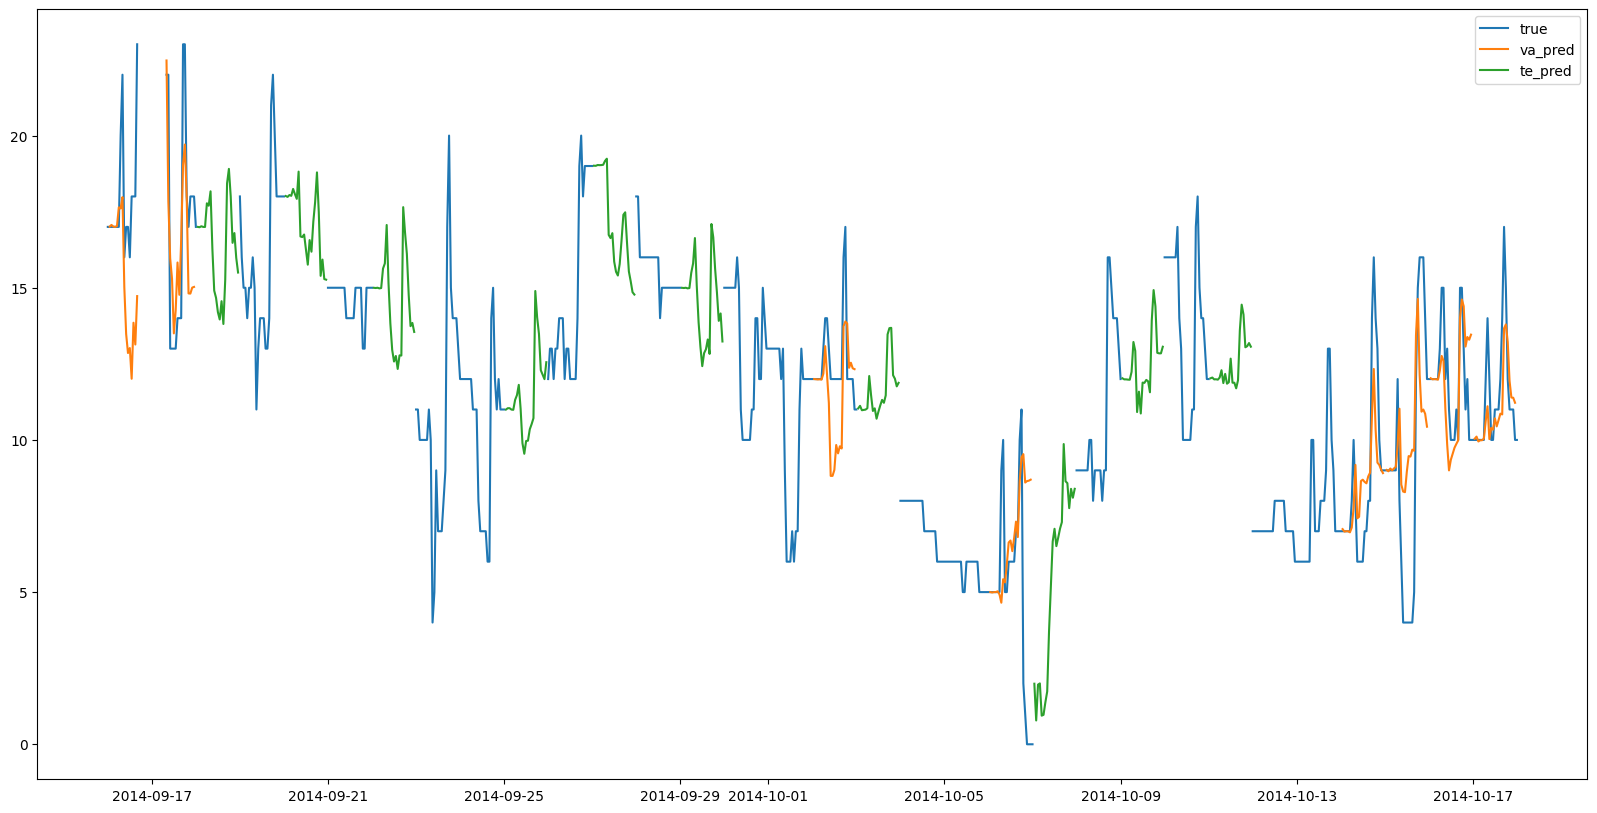

In [22]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル 需要・供給・介入の単純ラグ特徴量追加


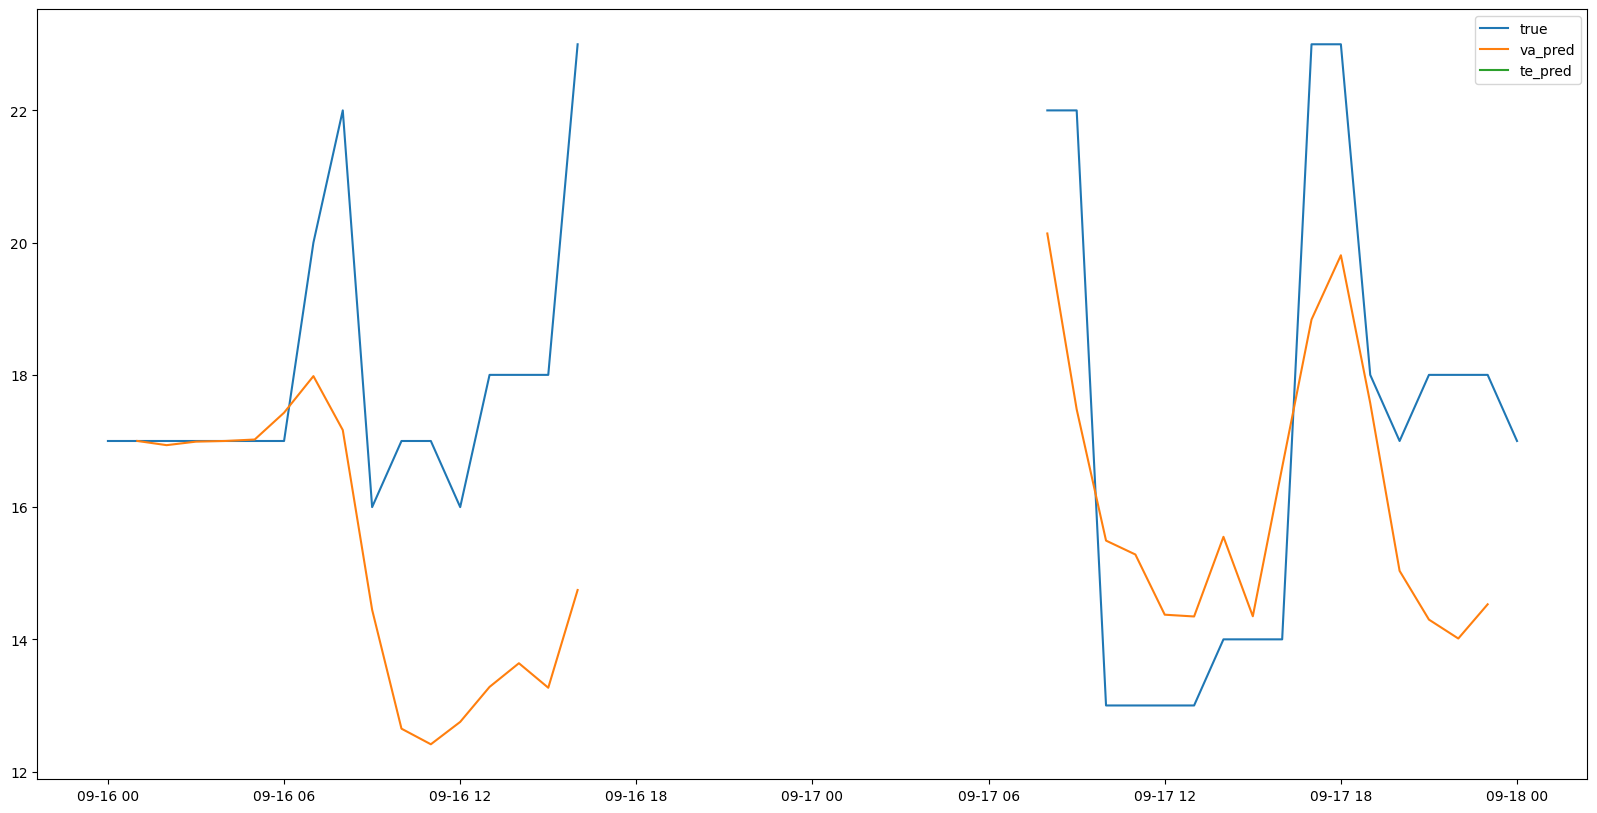

In [22]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル


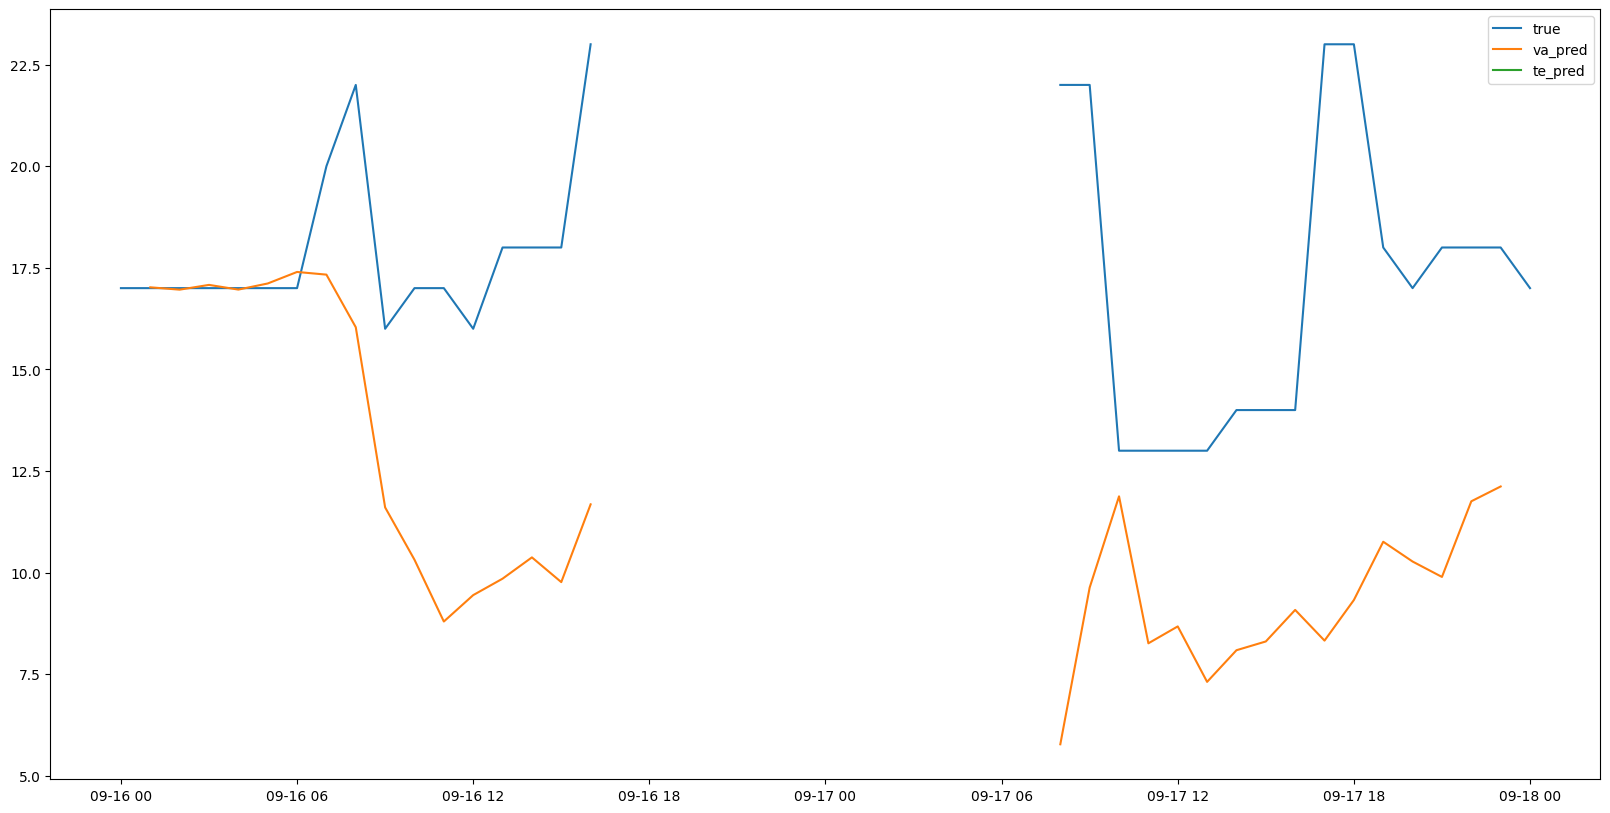

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LSTM_台数

In [ ]:
df_main_lstm_new = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lstm_new.pkl"))

In [ ]:
df_main_lstm_new

,station_id,datetime,predict,bikes_available,weekday
0,0,2013-09-01 00:00:00,0,11.0,6
1,1,2013-09-01 00:00:00,0,8.0,6
2,2,2013-09-01 00:00:00,0,5.0,6
3,3,2013-09-01 00:00:00,0,9.0,6
4,4,2013-09-01 00:00:00,0,8.0,6
...,...,...,...,...,...
1226395,65,2015-08-31 23:00:00,0,13.0,0
1226396,66,2015-08-31 23:00:00,0,7.0,0
1226397,67,2015-08-31 23:00:00,0,6.0,0
1226398,68,2015-08-31 23:00:00,0,5.0,0


In [ ]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from datetime import datetime
from src.util import Logger

In [ ]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [ ]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [ ]:
logger = Logger(path=DIR_LOG)

In [ ]:
run_name = get_run_name(model_type="lstm_mult")
# run_name = 'lstm_mult_202410132245'
run_name

'lstm_mult_202410181108'

In [ ]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [ ]:
model_params = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "seq_length": 24,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 10,
    "learning_rate": 0.001,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [ ]:
memo = "LSTMのマルチステップ予測 後処理追加"
timeseries_runner = TimeseriesModelRunner(run_name,
                                          model_LSTM_mult,
                                          model_params,
                                          df_main_lstm_new,
                                          run_setting,
                                          cv_setting,
                                          logger,
                                          memo)

In [ ]:
timeseries_runner.run_train_cv()

[2024-10-18 11:08:36] - lstm_mult_202410181108 - start training cv
[2024-10-18 11:08:36] - lstm_mult_202410181108 fold 2014-09-01 - start training


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
24576 24576
(24576, 24, 2) (24576, 23)
torch.Size([24576, 24, 2]) torch.Size([24576, 23])
24576
384
2
model
criterion


In [ ]:
timeseries_runner.run_metric_cv()

[2024-10-14 14:48:08] - lstm_mult_202410132245 - start metric cv
100%|██████████| 12/12 [00:23<00:00,  1.95s/it]
memo: LSTMのマルチステップ予測 後処理追加
run_name:lstm_mult_202410132245	score_mean:1.6819826614430216	score0:1.7368062295534643	score1:1.8970805470764205	score2:1.6028723657051864	score3:1.658505381214091	score4:1.6624859627015631	score5:1.5040819079485985	score6:1.702690100422395	score7:1.622700958258432	score8:1.617622394960939	score9:1.7418933251045943	score10:1.793829023956512	score11:1.6432237404140626
mean: 1.6819826614430216, std: 0.09738140548426347
[2024-10-14 14:48:31] - mean: 1.6819826614430216, std: 0.09738140548426347
[2024-10-14 14:48:31] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410132245/va_pred.pkl
[2024-10-14 14:48:31] - lstm_mult_202410132245 - end metric cv


In [ ]:
timeseries_runner.run_predict_cv()

[2024-10-14 14:50:09] - lstm_mult_202410132245 - start prediction cv
100%|██████████| 12/12 [00:38<00:00,  3.17s/it]
[2024-10-14 14:50:48] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410132245/te_pred.pkl
[2024-10-14 14:50:48] - lstm_mult_202410132245 - end prediction cv


In [ ]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LSTMのマルチステップ予測 学習率0.001 epoch5


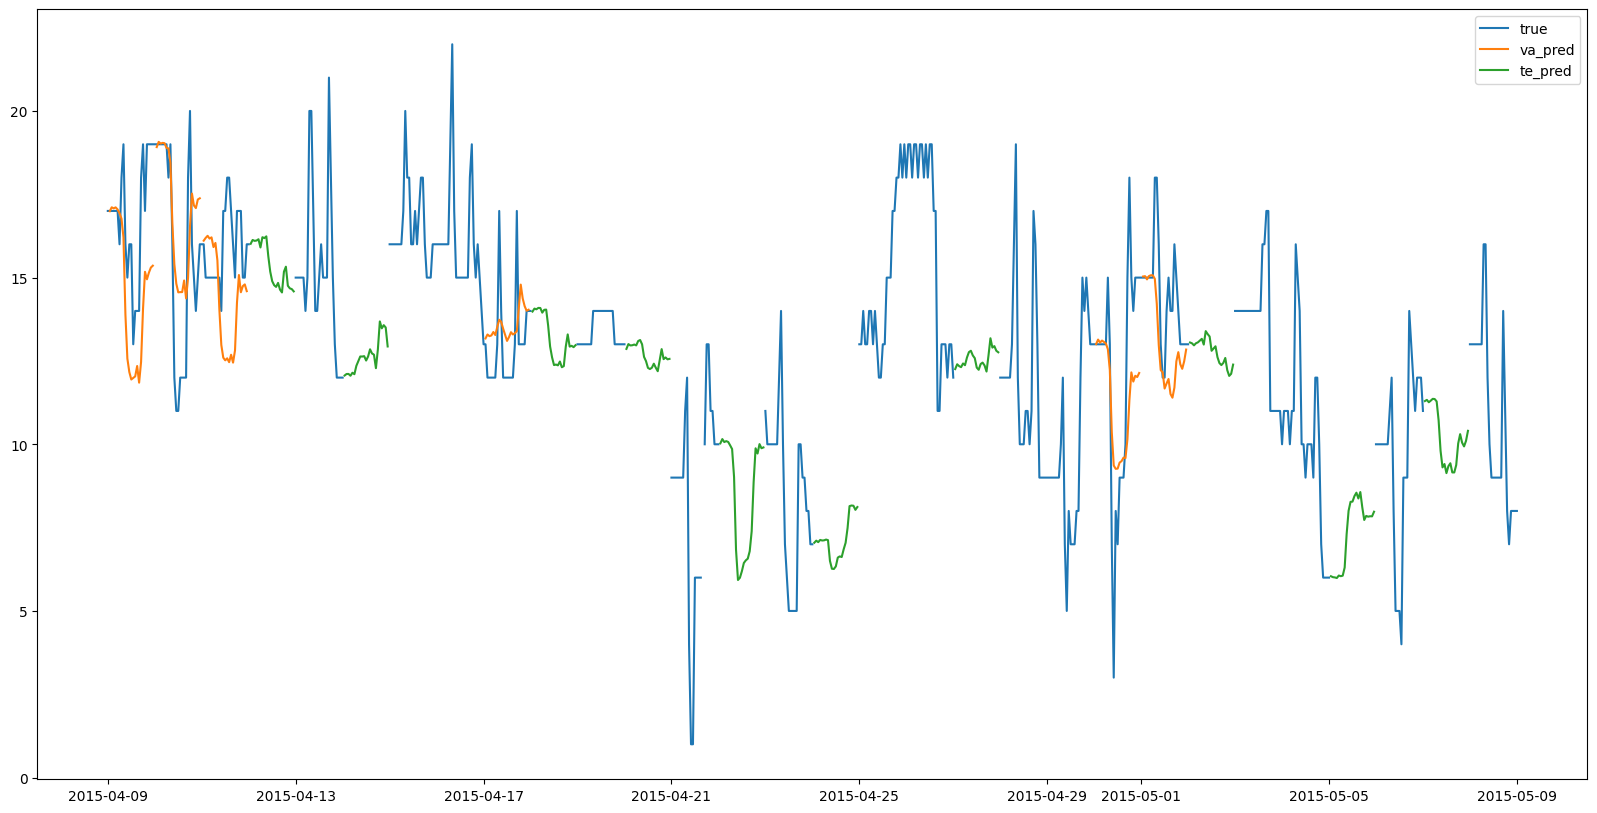

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LSTMのマルチステップ予測 学習率0.001 epoch5


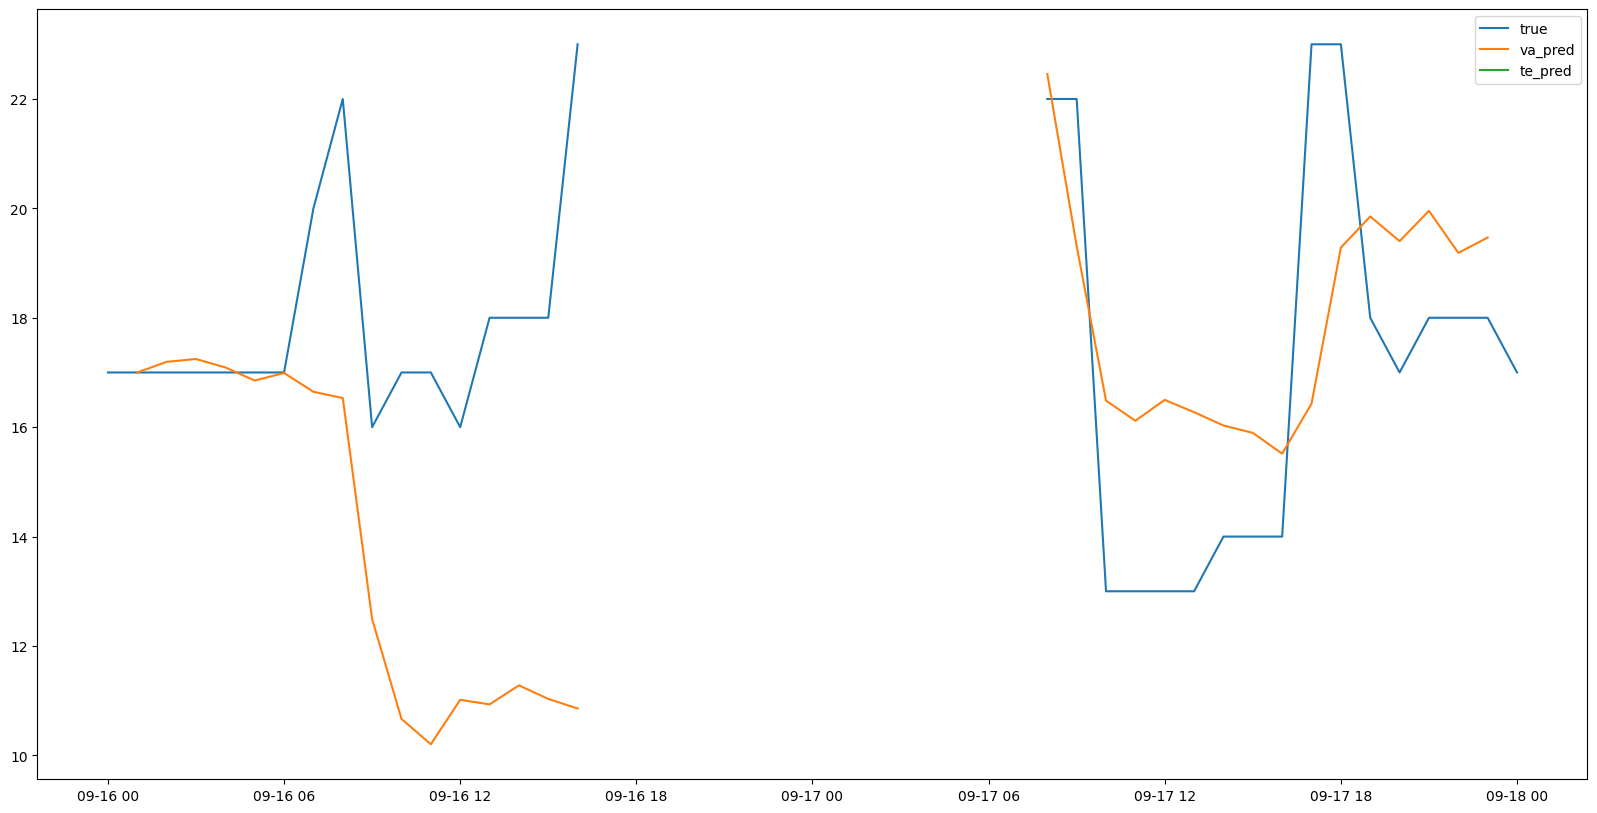

In [ ]:
# 元の目的関数が欠損している部分（）
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
# 学習データ数の推移
for month in range(8, 13):
    i_fold = datetime(2014, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

for month in range(1, 9):
    i_fold = datetime(2015, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

2014-08-01 00:00:00 (22406, 24, 2)
2014-09-01 00:00:00 (24576, 24, 2)
2014-10-01 00:00:00 (25276, 24, 2)
2014-11-01 00:00:00 (26046, 24, 2)
2014-12-01 00:00:00 (26746, 24, 2)
2015-01-01 00:00:00 (27516, 24, 2)
2015-02-01 00:00:00 (28286, 24, 2)
2015-03-01 00:00:00 (28846, 24, 2)
2015-04-01 00:00:00 (29616, 24, 2)
2015-05-01 00:00:00 (30316, 24, 2)
2015-06-01 00:00:00 (31086, 24, 2)
2015-07-01 00:00:00 (31786, 24, 2)
2015-08-01 00:00:00 (32556, 24, 2)


# LGBM_需要

In [ ]:

df_main_demand = df_key.copy()
df_main_demand = pd.merge(df_main_demand, df_predict, on=["station_id","datetime"], how="left")
df_main_demand = pd.merge(df_main_demand, df_target_detail[["station_id","datetime","demand_cumsum"]], on=["station_id","datetime"], how="left")
df_main_demand = pd.merge(df_main_demand, df_target_detail_lag, on=["station_id","datetime"], how="left")
df_main_demand = pd.merge(df_main_demand, df_weekday, on=["datetime"], how="left")

df_main_new_demand = create_add_valid_dataset(df_main_demand)


In [ ]:
# datasetの作成
df_main_demand = load_feature("df_key")
df_main_demand = pd.merge(df_main_demand, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_demand = pd.merge(df_main_demand, load_feature("df_demand_cumsum_fillna"), on=["station_id", "datetime"], how="left")

In [ ]:
df_main_new_demand.to_pickle(os.path.join(DIR_INTERIM, "df_main_new_demand.pkl"))

In [ ]:
df_main_new_demand = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_new_demand.pkl"))

In [ ]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [ ]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [ ]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_demand")
run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_demand_202410142258'

In [ ]:
# ロガーの設定
logger = Logger(path=DIR_LOG)


In [ ]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(upper=0)

    return df_pred

In [ ]:
model_params_lgb_demand = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 2000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_demand = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_demand = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [ ]:
memo = "LightGBM23期マルチモデル demand_cumsum"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_demand,
    df_main_new_demand,
    run_setting_lgb_demand,
    cv_setting_lgb_demand,
    logger,
    memo)

In [ ]:
ml_runner.run_train_cv()

[2024-10-14 22:58:24] - lgbm_multiml_demand_202410142258 - start training cv
[2024-10-14 22:58:24] - lgbm_multiml_demand_202410142258 fold 2014-09-01 - start training


term: 1, tr_x: (23380, 76), tr_y: (23380, 1), va_x: (2170, 76), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3797
[LightGBM] [Info] Number of data points in the train set: 23380, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0873851	eval's l1: 0.103038
[200]	train's l1: 0.0716833	eval's l1: 0.0847514
[300]	train's l1: 0.065936	eval's l1: 0.0780581
[400]	train's l1: 0.0638322	eval's l1: 0.0756081
[500]	train's l1: 0.0630622	eval's l1: 0.0747113
[600]	train's l1: 0.0627804	eval's l1: 0.0743831
[700]	train's l1: 0.0626772	eval's l1: 0.0742629
[800]	train's l1: 0.0626394	eval's l1: 0.0742189
[900]	train's l1: 0.0626256	eval's l1: 0.0742028
[1000]	train's l1: 0.0626205	eval's l1: 0.074197
[1100]	train's l1

[2024-10-14 23:00:59] - lgbm_multiml_demand_202410142258 fold 2014-09-01 - end training
[2024-10-14 23:00:59] - lgbm_multiml_demand_202410142258 fold 2014-10-01 - start training


term: 1, tr_x: (25550, 76), tr_y: (25550, 1), va_x: (420, 76), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3999
[LightGBM] [Info] Number of data points in the train set: 25550, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0887145	eval's l1: 0.102974
[200]	train's l1: 0.0727932	eval's l1: 0.0875034
[300]	train's l1: 0.0669655	eval's l1: 0.0818408
[400]	train's l1: 0.0648324	eval's l1: 0.0797681
[500]	train's l1: 0.0640516	eval's l1: 0.0790095
[600]	train's l1: 0.0637658	eval's l1: 0.0787318
[700]	train's l1: 0.0636612	eval's l1: 0.0786301
[800]	train's l1: 0.0636229	eval's l1: 0.0785929
[900]	train's l1: 0.0636089	eval's l1: 0.0785793
[1000]	train's l1: 0.0636037	eval's l1: 0.0785743
[1100]	train's l1

[2024-10-14 23:02:49] - lgbm_multiml_demand_202410142258 fold 2014-10-01 - end training
[2024-10-14 23:02:49] - lgbm_multiml_demand_202410142258 fold 2014-11-01 - start training


...

[2024-10-14 23:33:06] - lgbm_multiml_demand_202410142258 fold 2015-06-01 - end training
[2024-10-14 23:33:06] - lgbm_multiml_demand_202410142258 fold 2015-07-01 - start training


term: 1, tr_x: (44660, 76), tr_y: (44660, 1), va_x: (280, 76), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4764
[LightGBM] [Info] Number of data points in the train set: 44660, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0862966	eval's l1: 0.0348872
[200]	train's l1: 0.070028	eval's l1: 0.0241133
[300]	train's l1: 0.0640732	eval's l1: 0.0201698
[400]	train's l1: 0.0618935	eval's l1: 0.0187263
[500]	train's l1: 0.0610957	eval's l1: 0.0181979
[600]	train's l1: 0.0608036	eval's l1: 0.0180045
[700]	train's l1: 0.0606967	eval's l1: 0.0179337
[800]	train's l1: 0.0606576	eval's l1: 0.0179078
[900]	train's l1: 0.0606433	eval's l1: 0.0178983
[1000]	train's l1: 0.060638	eval's l1: 0.0178949
[1100]	train's l1:

[2024-10-14 23:36:16] - lgbm_multiml_demand_202410142258 fold 2015-07-01 - end training
[2024-10-14 23:36:16] - lgbm_multiml_demand_202410142258 fold 2015-08-01 - start training


term: 1, tr_x: (46760, 76), tr_y: (46760, 1), va_x: (350, 76), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006997 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4781
[LightGBM] [Info] Number of data points in the train set: 46760, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0855963	eval's l1: 0.0793565
[200]	train's l1: 0.0694678	eval's l1: 0.0634443
[300]	train's l1: 0.0635642	eval's l1: 0.0576199
[400]	train's l1: 0.0614033	eval's l1: 0.055488
[500]	train's l1: 0.0606124	eval's l1: 0.0547077
[600]	train's l1: 0.0603228	eval's l1: 0.0544221
[700]	train's l1: 0.0602169	eval's l1: 0.0543175
[800]	train's l1: 0.0601781	eval's l1: 0.0542792
[900]	train's l1: 0.0601639	eval's l1: 0.0542652
[1000]	train's l1: 0.0601587	eval's l1: 0.0542601
[1100]	train's l1

[2024-10-14 23:39:10] - lgbm_multiml_demand_202410142258 fold 2015-08-01 - end training
[2024-10-14 23:39:10] - lgbm_multiml_demand_202410142258 - end training cv


In [ ]:
ml_runner.run_metric_cv()

[2024-10-15 16:47:27] - lgbm_multiml_demand_202410142258 - start metric cv
100%|██████████| 12/12 [03:57<00:00, 19.77s/it]
memo: LightGBM23期マルチモデル demand_cumsum
run_name:lgbm_multiml_demand_202410142258	score_mean:2.2507819233241975	score0:2.345910104402896	score1:2.344884720360136	score2:3.0850323653663043	score3:1.3618085294342033	score4:2.1062527879190407	score5:2.4927756248810184	score6:2.3263839264255113	score7:1.6118102714642555	score8:1.6074637485535763	score9:3.0685704553691773	score10:2.3470963222588477	score11:2.3113942234554017
mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/va_pred.pkl
[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - end metric cv


In [ ]:
ml_runner.run_predict_cv()

[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - start prediction cv
100%|██████████| 12/12 [03:32<00:00, 17.73s/it]
[2024-10-15 16:54:58] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/te_pred.pkl
[2024-10-15 16:54:58] - lgbm_multiml_demand_202410142258 - end prediction cv


In [ ]:
ml_runner.plot_feature_importance_cv()

[2024-10-15 16:54:58] - lgbm_multiml_demand_202410142258 - start plot feature importance cv
[2024-10-15 16:55:38] - lgbm_multiml_demand_202410142258 - end plot feature importance cv


In [ ]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_new_demand[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル demand_cumsum


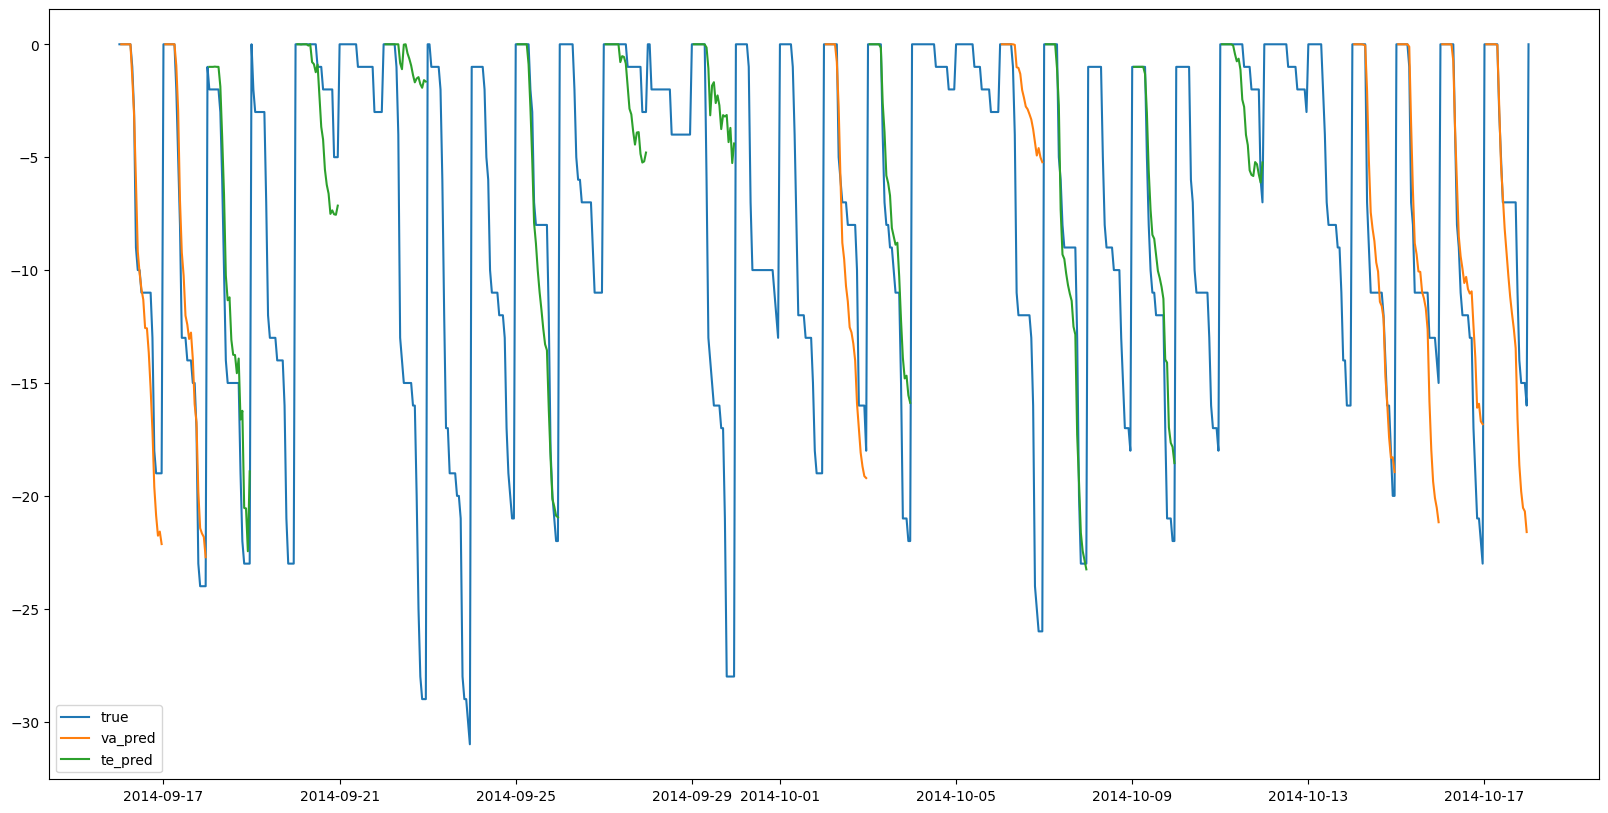

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_供給

In [ ]:

df_main_supply = df_key.copy()
df_main_supply = pd.merge(df_main_supply, df_predict, on=["station_id","datetime"], how="left")
df_main_supply = pd.merge(df_main_supply, df_target_detail[["station_id","datetime","supply_cumsum"]], on=["station_id","datetime"], how="left")
df_main_supply = pd.merge(df_main_supply, df_target_detail_lag, on=["station_id","datetime"], how="left")
df_main_supply = pd.merge(df_main_supply, df_weekday, on=["datetime"], how="left")

df_main_new_supply = create_add_valid_dataset(df_main_supply)


In [ ]:
df_main_new_supply.to_pickle(os.path.join(DIR_INTERIM, "df_main_new_supply.pkl"))

In [ ]:
df_main_new_supply = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_new_supply.pkl"))

In [ ]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [ ]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [ ]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_supply")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_supply_202410151702'

In [ ]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

In [ ]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)

    return df_pred

In [ ]:
model_params_lgb_supply = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 2000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_supply = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_supply = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [ ]:
memo = "LightGBM23期マルチモデル demand_supply"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_supply,
    df_main_new_supply,
    run_setting_lgb_supply,
    cv_setting_lgb_supply,
    logger,
    memo)

In [ ]:
ml_runner.run_train_cv()

[2024-10-15 17:08:09] - lgbm_multiml_supply_202410151702 - start training cv
[2024-10-15 17:08:09] - lgbm_multiml_supply_202410151702 fold 2014-09-01 - start training


term: 1, tr_x: (23380, 76), tr_y: (23380, 1), va_x: (2170, 76), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3797
[LightGBM] [Info] Number of data points in the train set: 23380, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0995893	eval's l1: 0.117866
[200]	train's l1: 0.0825476	eval's l1: 0.0992589
[300]	train's l1: 0.0763098	eval's l1: 0.0924482
[400]	train's l1: 0.0740266	eval's l1: 0.0899552
[500]	train's l1: 0.0731908	eval's l1: 0.0890427
[600]	train's l1: 0.0728849	eval's l1: 0.0887087
[700]	train's l1: 0.072773	eval's l1: 0.0885864
[800]	train's l1: 0.072732	eval's l1: 0.0885417
[900]	train's l1: 0.072717	eval's l1: 0.0885253
[1000]	train's l1: 0.0727115	eval's l1: 0.0885193
[1100]	train's l1:

[2024-10-15 17:10:26] - lgbm_multiml_supply_202410151702 fold 2014-09-01 - end training
[2024-10-15 17:10:26] - lgbm_multiml_supply_202410151702 fold 2014-10-01 - start training


term: 1, tr_x: (25550, 76), tr_y: (25550, 1), va_x: (420, 76), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3999
[LightGBM] [Info] Number of data points in the train set: 25550, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.101141	eval's l1: 0.109269
[200]	train's l1: 0.0839666	eval's l1: 0.0943511
[300]	train's l1: 0.0776801	eval's l1: 0.0888907
[400]	train's l1: 0.075379	eval's l1: 0.0868921
[500]	train's l1: 0.0745368	eval's l1: 0.0861605
[600]	train's l1: 0.0742285	eval's l1: 0.0858927
[700]	train's l1: 0.0741156	eval's l1: 0.0857947
[800]	train's l1: 0.0740743	eval's l1: 0.0857588
[900]	train's l1: 0.0740592	eval's l1: 0.0857457
[1000]	train's l1: 0.0740537	eval's l1: 0.0857409
[1100]	train's l1: 

[2024-10-15 17:12:37] - lgbm_multiml_supply_202410151702 fold 2014-10-01 - end training
[2024-10-15 17:12:37] - lgbm_multiml_supply_202410151702 fold 2014-11-01 - start training


...

[2024-10-15 17:33:41] - lgbm_multiml_supply_202410151702 fold 2015-06-01 - end training
[2024-10-15 17:33:41] - lgbm_multiml_supply_202410151702 fold 2015-07-01 - start training


term: 1, tr_x: (44660, 76), tr_y: (44660, 1), va_x: (280, 76), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4764
[LightGBM] [Info] Number of data points in the train set: 44660, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0990123	eval's l1: 0.0459161
[200]	train's l1: 0.0815954	eval's l1: 0.032656
[300]	train's l1: 0.0752202	eval's l1: 0.0278023
[400]	train's l1: 0.0728867	eval's l1: 0.0260257
[500]	train's l1: 0.0720326	eval's l1: 0.0253755
[600]	train's l1: 0.0717199	eval's l1: 0.0251374
[700]	train's l1: 0.0716055	eval's l1: 0.0250503
[800]	train's l1: 0.0715636	eval's l1: 0.0250184
[900]	train's l1: 0.0715483	eval's l1: 0.0250067
[1000]	train's l1: 0.0715426	eval's l1: 0.0250025
[1100]	train's l1

[2024-10-15 17:37:02] - lgbm_multiml_supply_202410151702 fold 2015-07-01 - end training
[2024-10-15 17:37:02] - lgbm_multiml_supply_202410151702 fold 2015-08-01 - start training


term: 1, tr_x: (46760, 76), tr_y: (46760, 1), va_x: (350, 76), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4781
[LightGBM] [Info] Number of data points in the train set: 46760, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0981356	eval's l1: 0.0986195
[200]	train's l1: 0.080811	eval's l1: 0.0813813
[300]	train's l1: 0.0744697	eval's l1: 0.0750716
[400]	train's l1: 0.0721485	eval's l1: 0.072762
[500]	train's l1: 0.0712989	eval's l1: 0.0719167
[600]	train's l1: 0.0709879	eval's l1: 0.0716072
[700]	train's l1: 0.0708741	eval's l1: 0.071494
[800]	train's l1: 0.0708324	eval's l1: 0.0714525
[900]	train's l1: 0.0708172	eval's l1: 0.0714373
[1000]	train's l1: 0.0708116	eval's l1: 0.0714318
[1100]	train's l1: 

[2024-10-15 17:40:19] - lgbm_multiml_supply_202410151702 fold 2015-08-01 - end training
[2024-10-15 17:40:19] - lgbm_multiml_supply_202410151702 - end training cv


In [ ]:
ml_runner.run_metric_cv()

[2024-10-15 17:57:15] - lgbm_multiml_supply_202410151702 - start metric cv
100%|██████████| 12/12 [03:40<00:00, 18.39s/it]
memo: LightGBM23期マルチモデル demand_supply
run_name:lgbm_multiml_supply_202410151702	score_mean:2.2753274820602436	score0:2.4336771180545194	score1:2.4461572233096947	score2:3.028422754355578	score3:1.4349659157196566	score4:2.122129326270325	score5:2.65382056744003	score6:2.346879040070308	score7:1.4985730014631347	score8:1.567200323825077	score9:3.0634702108354754	score10:2.416111528386863	score11:2.292522774992263
mean: 2.2753274820602436, std: 0.5200593040862866
[2024-10-15 18:00:55] - mean: 2.2753274820602436, std: 0.5200593040862866
[2024-10-15 18:00:55] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_supply_202410151702/va_pred.pkl
[2024-10-15 18:00:55] - lgbm_multiml_supply_202410151702 - end metric cv


In [ ]:
ml_runner.run_predict_cv()

[2024-10-15 18:00:55] - lgbm_multiml_supply_202410151702 - start prediction cv
100%|██████████| 12/12 [03:34<00:00, 17.84s/it]
[2024-10-15 18:04:30] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_supply_202410151702/te_pred.pkl
[2024-10-15 18:04:30] - lgbm_multiml_supply_202410151702 - end prediction cv


In [ ]:
ml_runner.plot_feature_importance_cv()

[2024-10-15 18:04:30] - lgbm_multiml_supply_202410151702 - start plot feature importance cv
[2024-10-15 18:05:10] - lgbm_multiml_supply_202410151702 - end plot feature importance cv


In [ ]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_new_supply[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル demand_supply


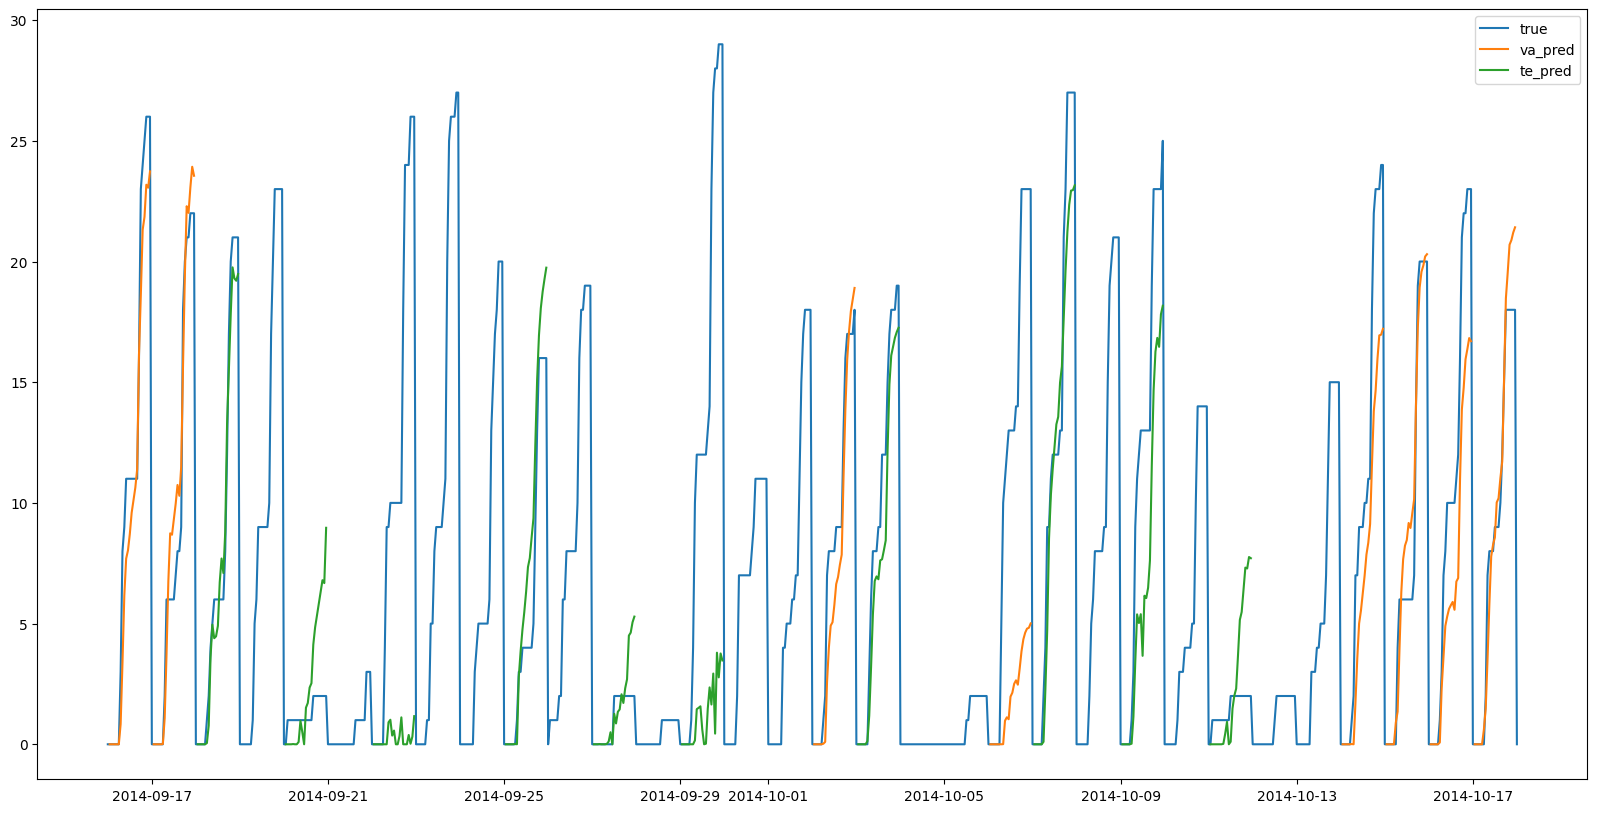

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_介入

In [ ]:

df_main_intervention = df_key.copy()
df_main_intervention = pd.merge(df_main_intervention, df_predict, on=["station_id","datetime"], how="left")
df_main_intervention = pd.merge(df_main_intervention, df_target_all[["station_id","datetime","intervention_cumsum"]], on=["station_id","datetime"], how="left")
df_main_intervention = pd.merge(df_main_intervention, df_target_detail_lag, on=["station_id","datetime"], how="left")
df_main_intervention = pd.merge(df_main_intervention, df_weekday, on=["datetime"], how="left")

df_main_new_intervention = create_add_valid_dataset(df_main_intervention)


In [ ]:
df_main_new_intervention.to_pickle(os.path.join(DIR_INTERIM, "df_main_new_intervention.pkl"))

In [ ]:
df_main_new_intervention = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_new_intervention.pkl"))

In [ ]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [ ]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [ ]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_intervention")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_intervention_202410151853'

In [ ]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

In [ ]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """

    return df_pred

In [ ]:
model_params_lgb_intervention = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 2000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_intervention = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_intervention = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [ ]:
memo = "LightGBM23期マルチモデル intervention_cumsum"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_intervention,
    df_main_new_intervention,
    run_setting_lgb_intervention,
    cv_setting_lgb_intervention,
    logger,
    memo)

In [ ]:
ml_runner.run_train_cv()

[2024-10-15 18:54:57] - lgbm_multiml_intervention_202410151853 - start training cv
[2024-10-15 18:54:57] - lgbm_multiml_intervention_202410151853 fold 2014-09-01 - start training


term: 1, tr_x: (22398, 76), tr_y: (22398, 1), va_x: (2168, 76), va_y: (2168, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3797
[LightGBM] [Info] Number of data points in the train set: 22398, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.068737	eval's l1: 0.0802745
[200]	train's l1: 0.0639929	eval's l1: 0.0759082
[300]	train's l1: 0.062239	eval's l1: 0.074139
[400]	train's l1: 0.0613753	eval's l1: 0.0732914
[500]	train's l1: 0.0607794	eval's l1: 0.072946
[600]	train's l1: 0.0602991	eval's l1: 0.0734743
Early stopping, best iteration is:
[525]	train's l1: 0.0606659	eval's l1: 0.0728325
term: 2, tr_x: (22329, 76), tr_y: (22329, 1), va_x: (2168, 76), va_y: (2168, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-thre

[2024-10-15 18:57:09] - lgbm_multiml_intervention_202410151853 fold 2014-09-01 - end training
[2024-10-15 18:57:09] - lgbm_multiml_intervention_202410151853 fold 2014-10-01 - start training


term: 1, tr_x: (24566, 76), tr_y: (24566, 1), va_x: (350, 76), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3999
[LightGBM] [Info] Number of data points in the train set: 24566, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.071024	eval's l1: 0.0577019
[200]	train's l1: 0.0671117	eval's l1: 0.0530474
[300]	train's l1: 0.065679	eval's l1: 0.0513437
[400]	train's l1: 0.0651409	eval's l1: 0.0507203
[500]	train's l1: 0.0649315	eval's l1: 0.0504928
[600]	train's l1: 0.0648462	eval's l1: 0.0504087
[700]	train's l1: 0.0648085	eval's l1: 0.0503777
[800]	train's l1: 0.0647845	eval's l1: 0.0503774
Early stopping, best iteration is:
[758]	train's l1: 0.0647949	eval's l1: 0.0503715
term: 2, tr_x: (24497, 76), tr_y:

[2024-10-15 18:58:51] - lgbm_multiml_intervention_202410151853 fold 2014-10-01 - end training
[2024-10-15 18:58:51] - lgbm_multiml_intervention_202410151853 fold 2014-11-01 - start training


...

[2024-10-15 19:14:28] - lgbm_multiml_intervention_202410151853 fold 2015-06-01 - end training
[2024-10-15 19:14:28] - lgbm_multiml_intervention_202410151853 fold 2015-07-01 - start training


term: 1, tr_x: (37305, 76), tr_y: (37305, 1), va_x: (280, 76), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4554
[LightGBM] [Info] Number of data points in the train set: 37305, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0756965	eval's l1: 0.0563891
[200]	train's l1: 0.0721611	eval's l1: 0.0547282
[300]	train's l1: 0.0708503	eval's l1: 0.0541072
[400]	train's l1: 0.0703443	eval's l1: 0.0538486
[500]	train's l1: 0.0701197	eval's l1: 0.0529551
[600]	train's l1: 0.0699891	eval's l1: 0.0525648
[700]	train's l1: 0.069837	eval's l1: 0.0523191
[800]	train's l1: 0.0696494	eval's l1: 0.0523034
[900]	train's l1: 0.0695197	eval's l1: 0.0521665
Early stopping, best iteration is:
[879]	train's l1: 0.0695426	eval

[2024-10-15 19:20:54] - lgbm_multiml_intervention_202410151853 fold 2015-07-01 - end training
[2024-10-15 19:20:54] - lgbm_multiml_intervention_202410151853 fold 2015-08-01 - start training


term: 1, tr_x: (38703, 76), tr_y: (38703, 1), va_x: (350, 76), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004766 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4580
[LightGBM] [Info] Number of data points in the train set: 38703, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0750117	eval's l1: 0.0618549
[200]	train's l1: 0.0714088	eval's l1: 0.0571905
[300]	train's l1: 0.0700901	eval's l1: 0.0554832
[400]	train's l1: 0.0695818	eval's l1: 0.0548547
[500]	train's l1: 0.0690578	eval's l1: 0.053825
[600]	train's l1: 0.0686781	eval's l1: 0.0524705
[700]	train's l1: 0.0685431	eval's l1: 0.0520101
[800]	train's l1: 0.0684098	eval's l1: 0.0518593
[900]	train's l1: 0.068248	eval's l1: 0.051855
Early stopping, best iteration is:
[849]	train's l1: 0.0683311	eval's

[2024-10-15 19:23:09] - lgbm_multiml_intervention_202410151853 fold 2015-08-01 - end training
[2024-10-15 19:23:09] - lgbm_multiml_intervention_202410151853 - end training cv


In [ ]:
ml_runner.run_metric_cv()

[2024-10-15 19:23:35] - lgbm_multiml_intervention_202410151853 - start metric cv
100%|██████████| 12/12 [04:05<00:00, 20.46s/it]
memo: LightGBM23期マルチモデル intervention_cumsum
run_name:lgbm_multiml_intervention_202410151853	score_mean:1.7212248859278116	score0:1.9853312730502588	score1:2.2363864495063335	score2:1.9383629507319897	score3:1.3091183158386546	score4:1.6443686689256	score5:1.6676085385734392	score6:1.5833785006487704	score7:1.585041290680082	score8:1.4268082636685213	score9:2.0353157099120605	score10:1.6811530169049949	score11:1.5618256526930367
mean: 1.7212248859278116, std: 0.2599361518344766
[2024-10-15 19:27:40] - mean: 1.7212248859278116, std: 0.2599361518344766
[2024-10-15 19:27:40] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_intervention_202410151853/va_pred.pkl
[2024-10-15 19:27:40] - lgbm_multiml_intervention_202410151853 - end metric cv


In [ ]:
ml_runner.run_predict_cv()

[2024-10-15 19:27:41] - lgbm_multiml_intervention_202410151853 - start prediction cv
100%|██████████| 12/12 [03:39<00:00, 18.31s/it]
[2024-10-15 19:31:20] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_intervention_202410151853/te_pred.pkl
[2024-10-15 19:31:20] - lgbm_multiml_intervention_202410151853 - end prediction cv


In [ ]:
ml_runner.plot_feature_importance_cv()

[2024-10-15 19:31:20] - lgbm_multiml_intervention_202410151853 - start plot feature importance cv
[2024-10-15 19:32:00] - lgbm_multiml_intervention_202410151853 - end plot feature importance cv


In [ ]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_new_intervention[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル intervention_cumsum


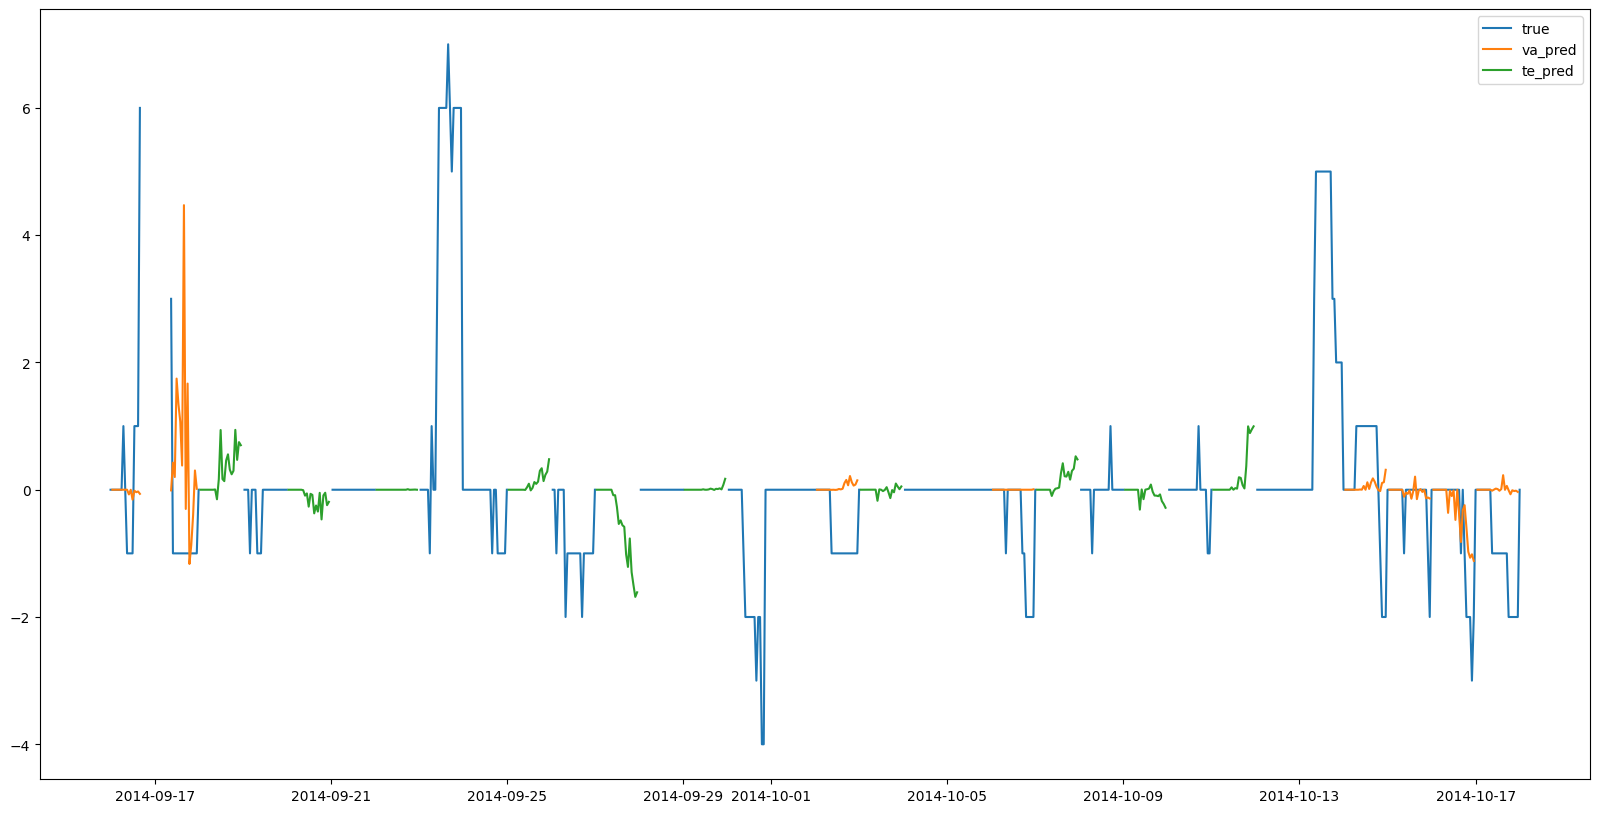

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [58]:
df_main_demand_lstm = df_key.copy()
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_predict_add_valid_flag, on=["station_id","datetime"], how="left")
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_demand_cumsum, on=["station_id","datetime"], how="left")
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_supply_cumsum, on=["station_id","datetime"], how="left")
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_weekday, on=["datetime"], how="left")

In [59]:
df_main_demand_lstm.to_pickle(os.path.join(DIR_INTERIM, "df_main_demand_lstm.pkl"))

In [60]:
df_main_demand_lstm = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_demand_lstm.pkl"))

In [66]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [62]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lstm_mult_demand")
# run_name = 'lstm_demand_202410142258'
run_name

'lstm_mult_demand_202410190321'

In [63]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(upper=0)

    return df_pred

model_params_lstm_demand = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "seq_length": 96,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 128,
    "num_epochs": 20,
    "learning_rate": 0.01,
    "weight_decay": 1e-5,
}
run_setting_lstm_demand = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lstm_demand = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [67]:
memo = "LSTM demand_cumsum supply_cumsumを追加"
timeseries_runner = TimeseriesModelRunner(
    run_name,
    model_LSTM_mult,
    model_params_lstm_demand,
    df_main_demand_lstm,
    run_setting_lstm_demand,
    cv_setting_lstm_demand,
    logger,
    memo)

In [68]:
timeseries_runner.run_train_cv()

[2024-10-19 03:24:10] - lstm_mult_demand_202410190321 - start training cv
INFO:../logs/general:[2024-10-19 03:24:10] - lstm_mult_demand_202410190321 - start training cv
[2024-10-19 03:24:10] - lstm_mult_demand_202410190321 fold 2014-09-01 - start training
INFO:../logs/general:[2024-10-19 03:24:10] - lstm_mult_demand_202410190321 fold 2014-09-01 - start training


(25270, 96, 3)
cuda
Epoch [1/20], Loss: 0.0237
Epoch [2/20], Loss: 0.0231
Epoch [3/20], Loss: 0.0191
Epoch [4/20], Loss: 0.0219
Epoch [5/20], Loss: 0.0163
Epoch [6/20], Loss: 0.0206
Epoch [7/20], Loss: 0.0180
Epoch [8/20], Loss: 0.0177
Epoch [9/20], Loss: 0.0179
Epoch [10/20], Loss: 0.0114
Epoch [11/20], Loss: 0.0132
Epoch [12/20], Loss: 0.0117
Epoch [13/20], Loss: 0.0153
Epoch [14/20], Loss: 0.0136
Epoch [15/20], Loss: 0.0141
Epoch [16/20], Loss: 0.0234
Epoch [17/20], Loss: 0.0148
Epoch [18/20], Loss: 0.0143
Epoch [19/20], Loss: 0.0130
Epoch [20/20], Loss: 0.0180


[2024-10-19 03:25:02] - lstm_mult_demand_202410190321 fold 2014-09-01 - end training
INFO:../logs/general:[2024-10-19 03:25:02] - lstm_mult_demand_202410190321 fold 2014-09-01 - end training
[2024-10-19 03:25:02] - lstm_mult_demand_202410190321 fold 2014-10-01 - start training
INFO:../logs/general:[2024-10-19 03:25:02] - lstm_mult_demand_202410190321 fold 2014-10-01 - start training


(27370, 96, 3)
cuda
Epoch [1/20], Loss: 0.0314
Epoch [2/20], Loss: 0.0199
Epoch [3/20], Loss: 0.0226
Epoch [4/20], Loss: 0.0201
Epoch [5/20], Loss: 0.0157
Epoch [6/20], Loss: 0.0183
Epoch [7/20], Loss: 0.0163
Epoch [8/20], Loss: 0.0117
Epoch [9/20], Loss: 0.0191
Epoch [10/20], Loss: 0.0161
Epoch [11/20], Loss: 0.0263
Epoch [12/20], Loss: 0.0103
Epoch [13/20], Loss: 0.0163
Epoch [14/20], Loss: 0.0146
Epoch [15/20], Loss: 0.0158
Epoch [16/20], Loss: 0.0119
Epoch [17/20], Loss: 0.0136
Epoch [18/20], Loss: 0.0101
Epoch [19/20], Loss: 0.0113
Epoch [20/20], Loss: 0.0157


[2024-10-19 03:25:55] - lstm_mult_demand_202410190321 fold 2014-10-01 - end training
INFO:../logs/general:[2024-10-19 03:25:55] - lstm_mult_demand_202410190321 fold 2014-10-01 - end training
[2024-10-19 03:25:55] - lstm_mult_demand_202410190321 fold 2014-11-01 - start training
INFO:../logs/general:[2024-10-19 03:25:55] - lstm_mult_demand_202410190321 fold 2014-11-01 - start training


...

[2024-10-19 03:35:20] - lstm_mult_demand_202410190321 fold 2015-06-01 - end training
INFO:../logs/general:[2024-10-19 03:35:20] - lstm_mult_demand_202410190321 fold 2015-06-01 - end training
[2024-10-19 03:35:20] - lstm_mult_demand_202410190321 fold 2015-07-01 - start training
INFO:../logs/general:[2024-10-19 03:35:20] - lstm_mult_demand_202410190321 fold 2015-07-01 - start training


(46480, 96, 3)
cuda
Epoch [1/20], Loss: 0.0203
Epoch [2/20], Loss: 0.0227
Epoch [3/20], Loss: 0.0229
Epoch [4/20], Loss: 0.0110
Epoch [5/20], Loss: 0.0159
Epoch [6/20], Loss: 0.0200
Epoch [7/20], Loss: 0.0173
Epoch [8/20], Loss: 0.0075
Epoch [9/20], Loss: 0.0119
Epoch [10/20], Loss: 0.0143
Epoch [11/20], Loss: 0.0109
Epoch [12/20], Loss: 0.0171
Epoch [13/20], Loss: 0.0148
Epoch [14/20], Loss: 0.0128
Epoch [15/20], Loss: 0.0125
Epoch [16/20], Loss: 0.0105
Epoch [17/20], Loss: 0.0060
Epoch [18/20], Loss: 0.0204
Epoch [19/20], Loss: 0.0118
Epoch [20/20], Loss: 0.0131


[2024-10-19 03:36:48] - lstm_mult_demand_202410190321 fold 2015-07-01 - end training
INFO:../logs/general:[2024-10-19 03:36:48] - lstm_mult_demand_202410190321 fold 2015-07-01 - end training
[2024-10-19 03:36:48] - lstm_mult_demand_202410190321 fold 2015-08-01 - start training
INFO:../logs/general:[2024-10-19 03:36:48] - lstm_mult_demand_202410190321 fold 2015-08-01 - start training


(48650, 96, 3)
cuda
Epoch [1/20], Loss: 0.0285
Epoch [2/20], Loss: 0.0141
Epoch [3/20], Loss: 0.0109
Epoch [4/20], Loss: 0.0095
Epoch [5/20], Loss: 0.0140
Epoch [6/20], Loss: 0.0147
Epoch [7/20], Loss: 0.0065
Epoch [8/20], Loss: 0.0106
Epoch [9/20], Loss: 0.0201
Epoch [10/20], Loss: 0.0110
Epoch [11/20], Loss: 0.0133
Epoch [12/20], Loss: 0.0095
Epoch [13/20], Loss: 0.0158
Epoch [14/20], Loss: 0.0089
Epoch [15/20], Loss: 0.0083
Epoch [16/20], Loss: 0.0110
Epoch [17/20], Loss: 0.0095
Epoch [18/20], Loss: 0.0078
Epoch [19/20], Loss: 0.0094
Epoch [20/20], Loss: 0.0069


[2024-10-19 03:38:21] - lstm_mult_demand_202410190321 fold 2015-08-01 - end training
INFO:../logs/general:[2024-10-19 03:38:21] - lstm_mult_demand_202410190321 fold 2015-08-01 - end training
[2024-10-19 03:38:21] - lstm_mult_demand_202410190321 - end training cv
INFO:../logs/general:[2024-10-19 03:38:21] - lstm_mult_demand_202410190321 - end training cv


In [69]:
timeseries_runner.run_metric_cv()

[2024-10-19 03:38:21] - lstm_mult_demand_202410190321 - start metric cv
INFO:../logs/general:[2024-10-19 03:38:21] - lstm_mult_demand_202410190321 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

hello
hello
hello
hello
hello
hello


  8%|▊         | 1/12 [00:02<00:30,  2.77s/it]

hello
hello
hello
hello
hello
hello


 17%|█▋        | 2/12 [00:05<00:28,  2.84s/it]

...

 83%|████████▎ | 10/12 [00:30<00:06,  3.15s/it]

hello
hello
hello
hello
hello


 92%|█████████▏| 11/12 [00:33<00:03,  3.18s/it]

hello
hello
hello
hello
hello


100%|██████████| 12/12 [00:37<00:00,  3.10s/it]
memo: LSTM demand_cumsum supply_cumsumを追加
INFO:../logs/result:memo: LSTM demand_cumsum supply_cumsumを追加
run_name:lstm_mult_demand_202410190321	score_mean:2.149402200804975	score0:2.2241234232611786	score1:2.1515772011339296	score2:2.7827455552732827	score3:1.5104594123289452	score4:2.253529555160807	score5:2.488832307824437	score6:2.3047974284835484	score7:1.7592984673695535	score8:1.8003446548198745	score9:2.741083004108127	score10:2.0983640870100224	score11:1.6776713128859952
INFO:../logs/result:run_name:lstm_mult_demand_202410190321	score_mean:2.149402200804975	score0:2.2241234232611786	score1:2.1515772011339296	score2:2.7827455552732827	score3:1.5104594123289452	score4:2.253529555160807	score5:2.488832307824437	score6:2.3047974284835484	score7:1.7592984673695535	score8:1.8003446548198745	score9:2.741083004108127	score10:2.0983640870100224	score11:1.6776713128859952
mean: 2.149402200804975, std: 0.3888450687068449
INFO:../logs/result:m

In [70]:
timeseries_runner.run_predict_cv()

[2024-10-19 03:38:58] - lstm_mult_demand_202410190321 - start prediction cv
INFO:../logs/general:[2024-10-19 03:38:58] - lstm_mult_demand_202410190321 - start prediction cv
  0%|          | 0/12 [00:00<?, ?it/s]

hello
hello
hello
hello
hello
hello
hello
hello
hello
hello


  8%|▊         | 1/12 [00:03<00:40,  3.69s/it]

hello
hello
hello
hello
hello
hello
hello
hello
hello
hello


 17%|█▋        | 2/12 [00:07<00:38,  3.80s/it]

...

 83%|████████▎ | 10/12 [00:45<00:09,  4.92s/it]

hello
hello
hello
hello
hello
hello
hello
hello
hello
hello


 92%|█████████▏| 11/12 [00:50<00:05,  5.13s/it]

hello
hello
hello
hello
hello
hello
hello
hello
hello
hello


100%|██████████| 12/12 [00:56<00:00,  4.71s/it]
[2024-10-19 03:39:54] - output predict : ../models/lstm_mult_demand_202410190321/te_pred.pkl
INFO:../logs/general:[2024-10-19 03:39:54] - output predict : ../models/lstm_mult_demand_202410190321/te_pred.pkl
[2024-10-19 03:39:54] - lstm_mult_demand_202410190321 - end prediction cv
INFO:../logs/general:[2024-10-19 03:39:54] - lstm_mult_demand_202410190321 - end prediction cv


In [71]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_demand_lstm[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LSTM demand_cumsum supply_cumsumを追加


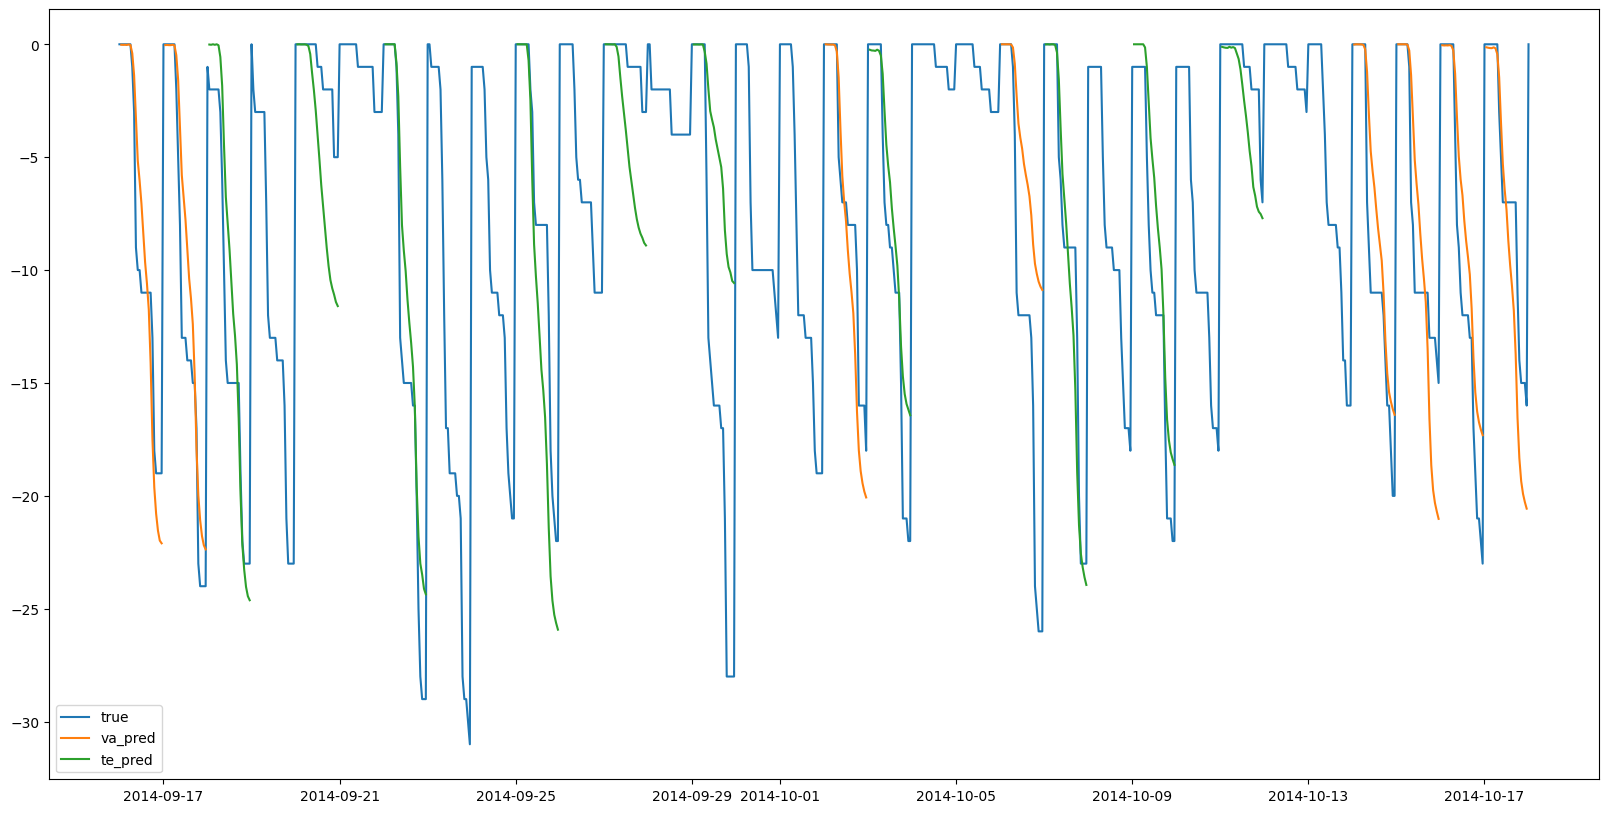

In [72]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LSTM demand_cumsum seq_length=96


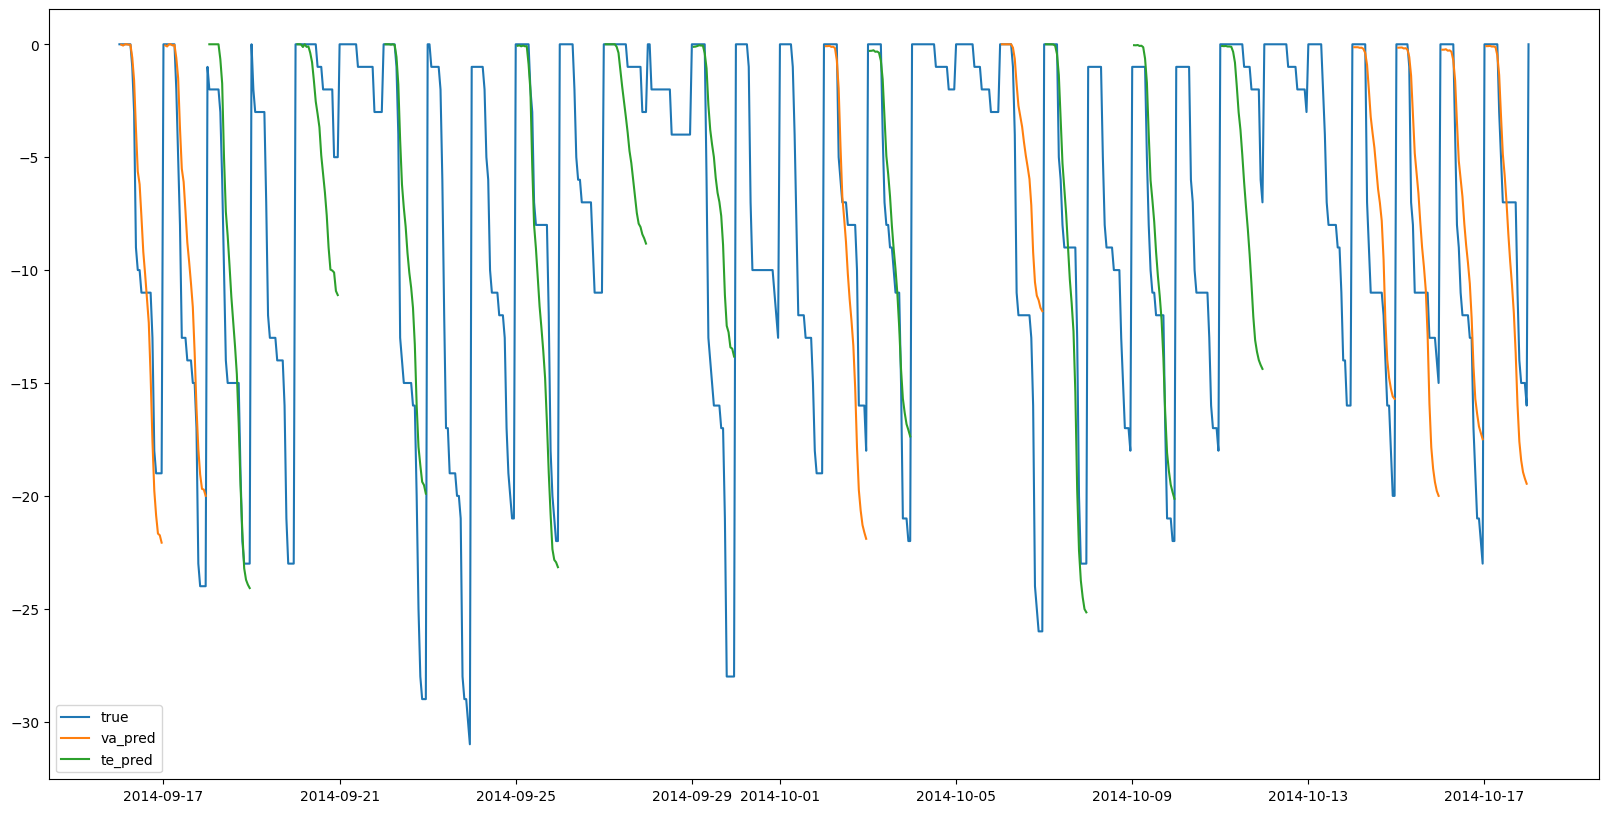

In [184]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# 需要＋供給＋介入

In [ ]:
def after_predict_process(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [ ]:
de_run_name = "lgbm_multiml_demand_202410142258"
de_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "va_pred.pkl"))
de_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "te_pred.pkl"))
de_va_te_pred = pd.concat([de_va_pred, de_te_pred], axis=0)
de_va_te_pred = de_va_te_pred.drop(columns=["target"])

In [ ]:
su_run_name = "lgbm_multiml_supply_202410151702"
su_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "va_pred.pkl"))
su_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "te_pred.pkl"))
su_va_te_pred = pd.concat([su_va_pred, su_te_pred], axis=0)
su_va_te_pred = su_va_te_pred.drop(columns=["target"])

In [ ]:
in_run_name = "lgbm_multiml_intervention_202410151853"
in_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "va_pred.pkl"))
in_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "te_pred.pkl"))
in_va_te_pred = pd.concat([in_va_pred, in_te_pred], axis=0)
in_va_te_pred = in_va_te_pred.drop(columns=["target"])

In [ ]:
df_predict_ = create_add_valid_dataset(df_predict)

In [ ]:
df_true_00 = df_target[df_target["datetime"].dt.hour==0][["station_id", "datetime", "bikes_available"]].copy()
df_true_00["date"] = df_true_00["datetime"].dt.date
df_true_00 = df_true_00.rename(columns={"bikes_available": "bikes_available_00"})
df_true_00 = df_true_00[["station_id", "date", "bikes_available_00"]]
df_pred = df_key.copy()
df_pred["date"] = df_pred["datetime"].dt.date
df_pred = pd.merge(df_pred, df_true_00, on=["station_id", "date"], how="left")
df_pred = df_pred[["station_id", "datetime", "bikes_available_00"]]

df_pred = df_pred.copy()
df_pred = pd.merge(df_pred, df_predict_, on=["station_id","datetime"], how="left")
df_pred = pd.merge(df_pred, de_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_de_va_pred"))
df_pred = pd.merge(df_pred, su_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_su_va_pred"))
df_pred = pd.merge(df_pred, in_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_in_va_pred"))

df_true = df_target[["station_id", "datetime", "bikes_available"]].copy()
df_true = pd.merge(df_true, df_predict_, on=["station_id", "datetime"], how="left")

In [ ]:
df_pred["bikes_available"] = df_pred["bikes_available_00"] + df_pred["demand_cumsum"] + df_pred["supply_cumsum"] + df_pred["intervention_cumsum"]

In [ ]:
df_metric = pd.merge(df_true, df_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_pred"))
df_metric = df_metric.dropna(subset=["bikes_available", "bikes_available_pred"])
df_metric = df_metric[df_metric["predict"]==2]
df_metric = df_metric.sort_values(["station_id", "datetime"])

In [ ]:
from sklearn.metrics import mean_absolute_error
def metric(va_true, va_pred):
    """評価指標の計算
    """
    score = mean_absolute_error(va_true, va_pred)
    # score = math.sqrt(mean_squared_error(va_true, va_pred))

    return score

metric(df_metric["bikes_available"].values,
       df_metric["bikes_available_pred"].values)

1.876879464472673

# LGBM_需要＋供給＋介入

In [ ]:
df_main_new_ans = df_key.copy()
df_main_new_ans = pd.merge(df_main_new_ans, df_bikes_available_fillna, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_predict_, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_demand_cumsum, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_supply_cumsum, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_intervention_cumsum, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_demand_cumsum_lag, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_supply_cumsum_lag, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_intervention_cumsum_lag, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_weekday, on=["datetime"], how="left")

In [8]:
df_main_demand_lstm = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_demand_lstm.pkl"))
df_main_supply_lstm = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_supply_lstm.pkl"))
df_main_intervention_lstm = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_intervention_lstm.pkl"))
df_main_new_ans = df_key.copy()
df_main_new_ans = pd.merge(df_main_new_ans, df_bikes_available_fillna, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_predict_, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_main_demand_lstm, on=["station_id","datetime"], how="left", suffixes=('', '_'))
df_main_new_ans = pd.merge(df_main_new_ans, df_main_supply_lstm, on=["station_id","datetime"], how="left", suffixes=('', '_'))
df_main_new_ans = pd.merge(df_main_new_ans, df_main_intervention_lstm, on=["station_id","datetime"], how="left", suffixes=('', '_'))

NameError: name 'df_key' is not defined

In [167]:
df_main_new_ans.to_pickle(os.path.join(DIR_INTERIM, "df_main_new_ans.pkl"))

In [37]:
df_main_new_ans = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_new_ans.pkl"))

In [18]:
import sys
sys.path.append(DIR_HOME)
from src.runner import MLModelRunner
from src.model_ASMBL import model_ASMBL_demand_supply_intervention
from src.model_LGBM import model_LGBM_multimodel
from datetime import datetime
from src.util import Logger

In [38]:
import importlib
from src import runner
from src import model_LGBM
from src import model_ASMBL
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model_ASMBL)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from src.model_LSTM_mult import model_LSTM_mult
from src.model_ASMBL import model_ASMBL_demand_supply_intervention

In [39]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="ansamble_lgbm")
# run_name = 'ansamble_lgbm_202410162243'
run_name

'ansamble_lgbm_202410190302'

In [40]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # model run params
    "demand_model_cls": model_LSTM_mult,
    "supply_model_cls": model_LSTM_mult,
    "intervention_model_cls": model_LSTM_mult,
    "demand_run_name": "lstm_mult_demand_202410181654",
    "supply_run_name": "lstm_mult_supply_202410181710",
    "intervention_run_name": "lstm_mult_intervention_202410181726",
    "num_boost_round": 2000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [41]:
memo = "アンサンブルLGBM ベースライン"
ml_runner = MLModelRunner(
    run_name,
    model_ASMBL_demand_supply_intervention,
    model_params_lgb,
    df_main_new_ans,
    run_setting,
    cv_setting,
    logger,
    memo)

In [42]:
df_main_new_ans.columns

Index(['station_id', 'datetime', 'bikes_available', 'predict', 'predict_',
       'demand_cumsum', 'weekday', 'predict_', 'supply_cumsum', 'weekday_',
       'predict_', 'intervention_cumsum', 'demand_cumsum_', 'supply_cumsum_',
       'weekday_'],
      dtype='object')

In [43]:
ml_runner.run_train_cv()

[2024-10-19 03:03:35] - ansamble_lgbm_202410190302 - start training cv
INFO:../logs/general:[2024-10-19 03:03:35] - ansamble_lgbm_202410190302 - start training cv
[2024-10-19 03:03:35] - ansamble_lgbm_202410190302 fold 2014-09-01 - start training
INFO:../logs/general:[2024-10-19 03:03:35] - ansamble_lgbm_202410190302 fold 2014-09-01 - start training


hello
['bikes_available', 'predict', 'predict_', 'demand_cumsum', 'weekday', 'predict_', 'supply_cumsum', 'weekday_', 'predict_', 'intervention_cumsum', 'demand_cumsum_', 'supply_cumsum_', 'weekday_', 'demand_cumsum']


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- bikes_available
- demand_cumsum_
- intervention_cumsum
- predict
- predict_
- ...


In [ ]:
ml_runner.run_metric_cv()

[2024-10-18 00:25:13] - ansamble_lgbm_202410171957 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

(10080, 83)


  8%|▊         | 1/12 [00:27<05:01, 27.36s/it]

(10080, 83)


 17%|█▋        | 2/12 [00:50<04:07, 24.75s/it]

...

 83%|████████▎ | 10/12 [04:38<00:57, 28.73s/it]

(8400, 83)


 92%|█████████▏| 11/12 [05:09<00:29, 29.26s/it]

(8400, 83)


100%|██████████| 12/12 [05:39<00:00, 28.29s/it]
memo: アンサンブルLGBM ベースライン
run_name:ansamble_lgbm_202410171957	score_mean:1.6723901286604053	score0:1.727677756413918	score1:1.9355701532712462	score2:1.5848849872761737	score3:1.5670274744746673	score4:1.6864676063980257	score5:1.4290685636210732	score6:1.6596108911811882	score7:1.6431221793277166	score8:1.6596329340896705	score9:1.75650352786577	score10:1.7835119798154075	score11:1.6356034901900067
mean: 1.6723901286604053, std: 0.11987545602176336
[2024-10-18 00:30:52] - mean: 1.6723901286604053, std: 0.11987545602176336
[2024-10-18 00:30:52] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/ansamble_lgbm_202410171957/va_pred.pkl
[2024-10-18 00:30:52] - ansamble_lgbm_202410171957 - end metric cv


In [ ]:
ml_runner.run_predict_cv()

[2024-10-18 00:30:54] - ansamble_lgbm_202410171957 - start prediction cv
100%|██████████| 12/12 [06:24<00:00, 32.06s/it]
[2024-10-18 00:37:18] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/ansamble_lgbm_202410171957/te_pred.pkl
[2024-10-18 00:37:18] - ansamble_lgbm_202410171957 - end prediction cv


In [ ]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

アンサンブルLGBM ベースライン


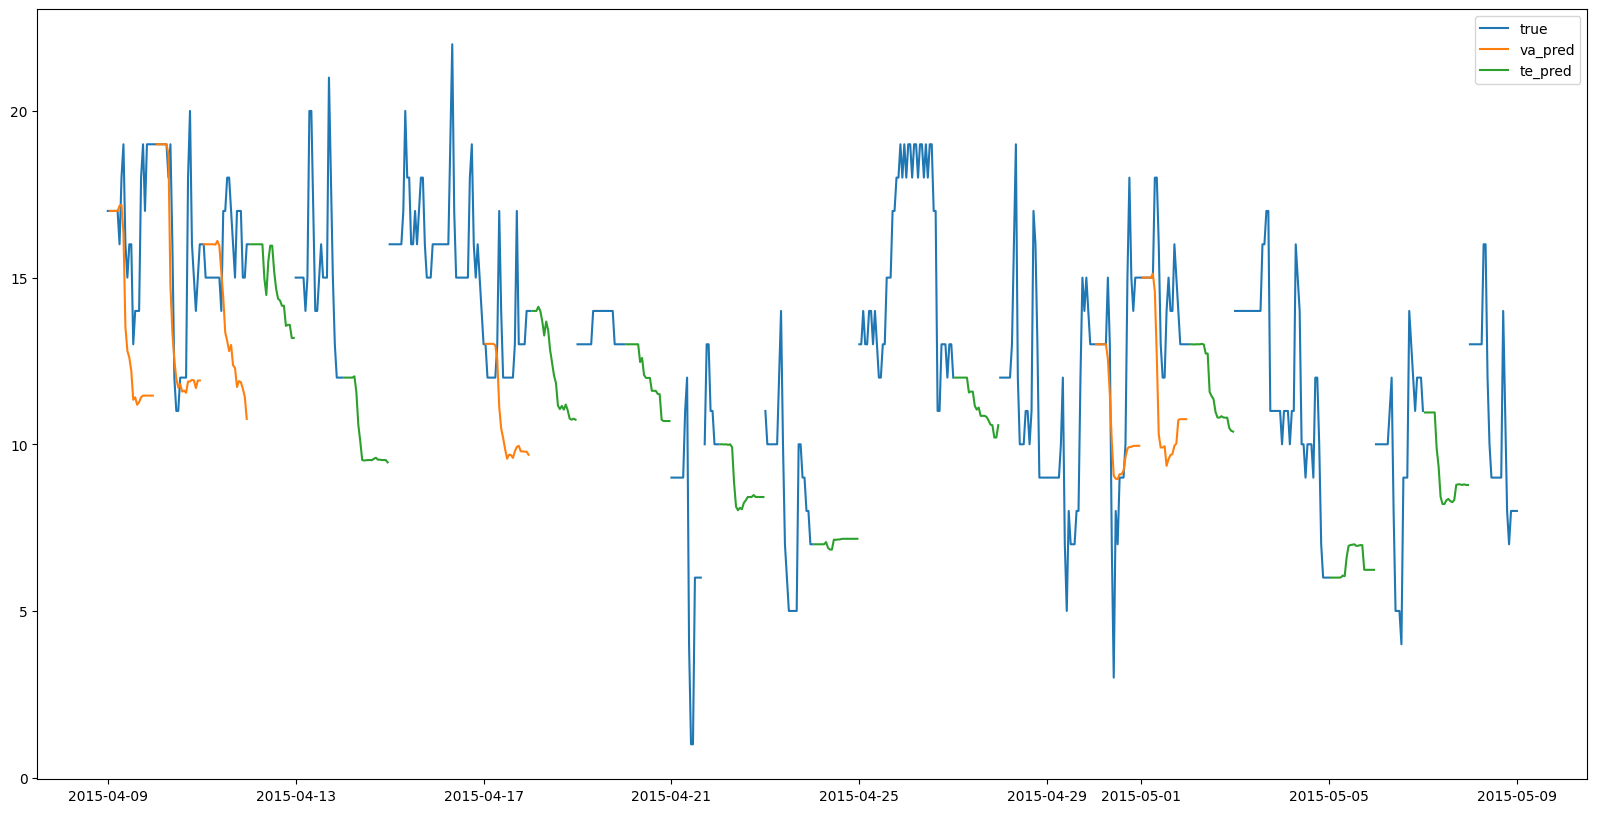

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# Submissionの作成

In [23]:
runner = ml_runner

In [24]:
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_te_pred = pd.read_pickle(path_te_pred)
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))[["id", "datetime", "station_id", "predict"]]

In [25]:
df_submit = pd.merge(df_prep_status, df_te_pred, on=["datetime", "station_id"], how="left")

In [27]:
df_sample_submit = pd.read_csv(os.path.join(DIR_INPUT, "sample_submit.csv"), header=None, names=["id", "b_a"])
df_submit = pd.merge(df_sample_submit, df_submit, on=["id"], how="left")[["id", "bikes_available"]]
path_submit = os.path.join(DIR_SUBMISSION, f"{runner.run_name}_submit.csv")
df_submit.to_csv(path_submit, header=False, index=False)
print(path_submit)

../data/submission/lgbm_multimodel_bikes_202410191901_submit.csv


In [28]:
pd.read_csv(path_submit, header=None)

,0,1
0,8761,15.009889
1,8762,14.998220
2,8763,14.997811
3,8764,14.990909
4,8765,14.989606
...,...,...
193195,1226347,9.856921
193196,1226348,9.803409
193197,1226349,10.104144
193198,1226350,10.202278
